In [1]:
import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from gpu import CRUs, RyR_stationary, LCC_stationary
from params import RestrepoParams
#from currents import get_ICa

In [2]:
ci = 0.1 * np.ones((200, 200), dtype=np.float32)
cs = 0.1 * np.ones((200, 200), dtype=np.float32)
cp = 0.1 * np.ones((200, 200), dtype=np.float32)

cjsr = 750.0 * np.ones((200,200), dtype=np.float32)
cnsr = 750.0 * np.ones((200,200), dtype=np.float32)

CaTi = 20.0 * np.ones((200,200), dtype=np.float32)
CaTs = 20.0 * np.ones((200,200), dtype=np.float32)

params = RestrepoParams(Ku=1.4e-4, h=2.5)

In [3]:
RyR = RyR_stationary(cp, params)

In [22]:
#LCC = LCC_stationary(cp, 0.1, params)
LCC = np.zeros((*cp.shape, 4), dtype=np.int32)
LCC[0, ...] = 2
LCC[-1, ...] = 2
LCC[:, 0, :] = 2
LCC[:, -1, :] = 2

In [65]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs)

In [66]:
cru_obj.forward(dt=2e-3, nstep=500_000, collect_every=500, _tpb2d=8, _tpb1d=16)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


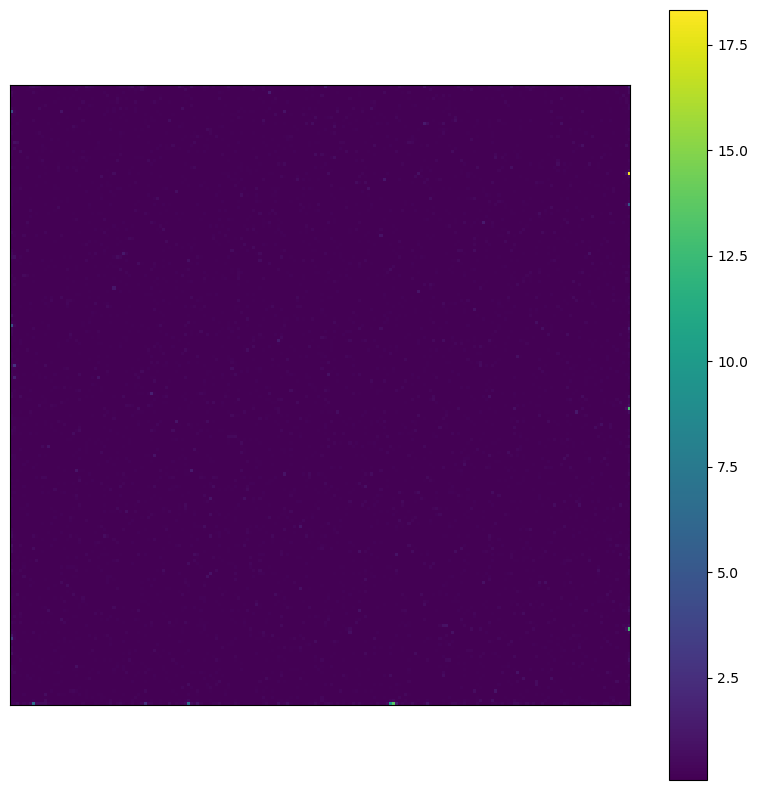

In [105]:
fig, ax = plt.subplots(1, figsize=(10,10))
im = ax.imshow(cru_obj.cs_result[-1, ...], aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
fig.colorbar(im)
plt.show()

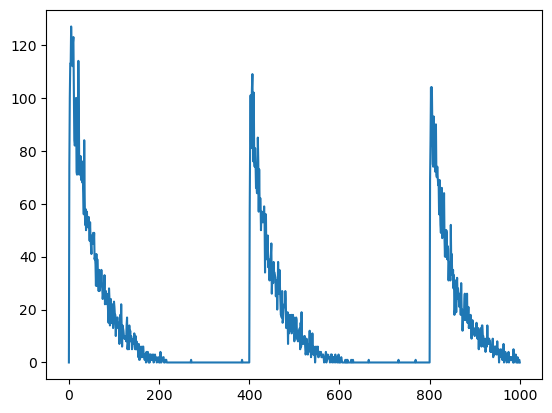

In [68]:
plt.plot(cru_obj.t, (cru_obj.LCC_result == 7).sum(axis=(1,2,3)))
plt.show()

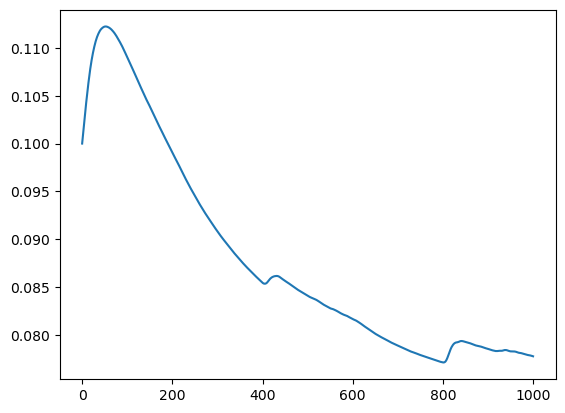

In [76]:
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

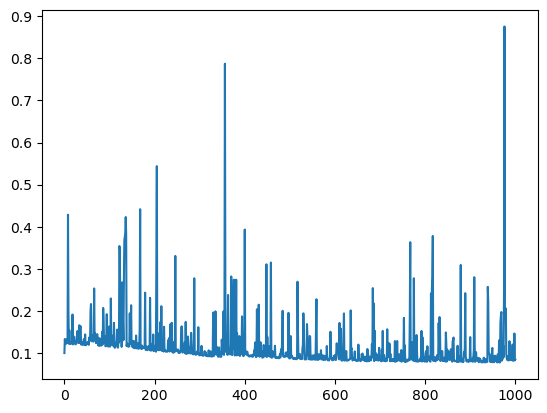

In [98]:
plt.plot(cru_obj.t, cru_obj.cs_result[:,10,10])
plt.show()

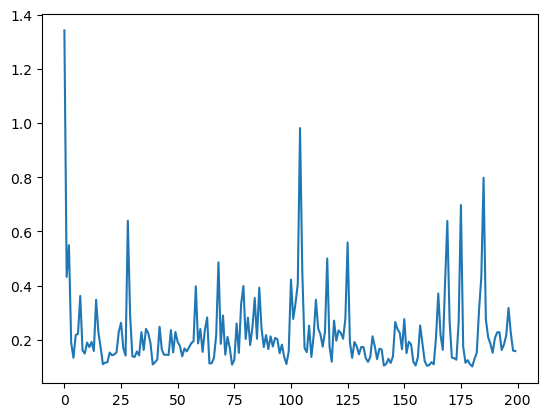

In [108]:
plt.plot(cru_obj.ci_result[-1, :, -1])
plt.show()

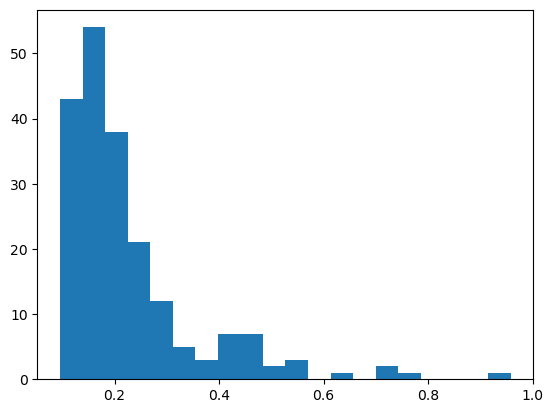

In [113]:
plt.hist(cru_obj.ci_result[-1, -1, :], bins=20)
plt.show()

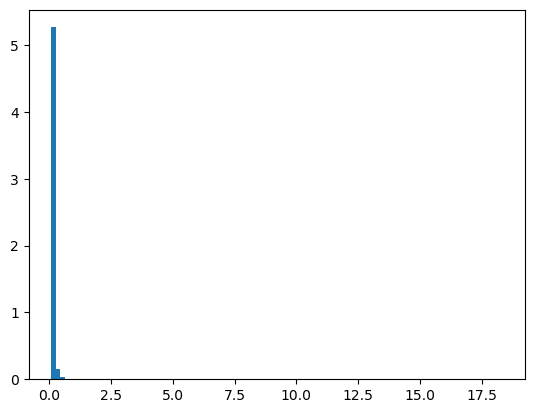

In [92]:
plt.hist(cru_obj.cs.reshape(-1), bins=100, density=True)
plt.show()

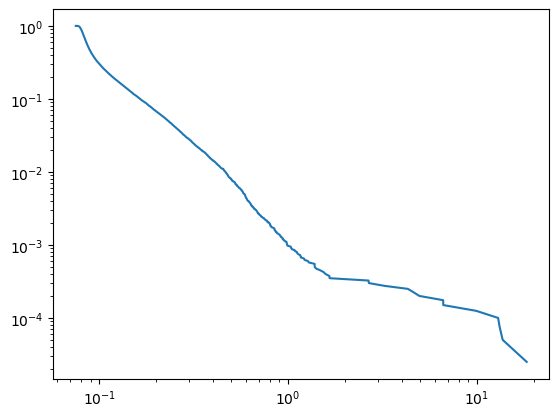

In [95]:
def ccdf(arr):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

ps, bins = ccdf(cru_obj.cs.reshape(-1))
plt.plot(bins, ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [77]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [84]:
modes = ifftshift(fft2(fftshift((cru_obj.ci - cru_obj.ci.mean())), norm="ortho"))

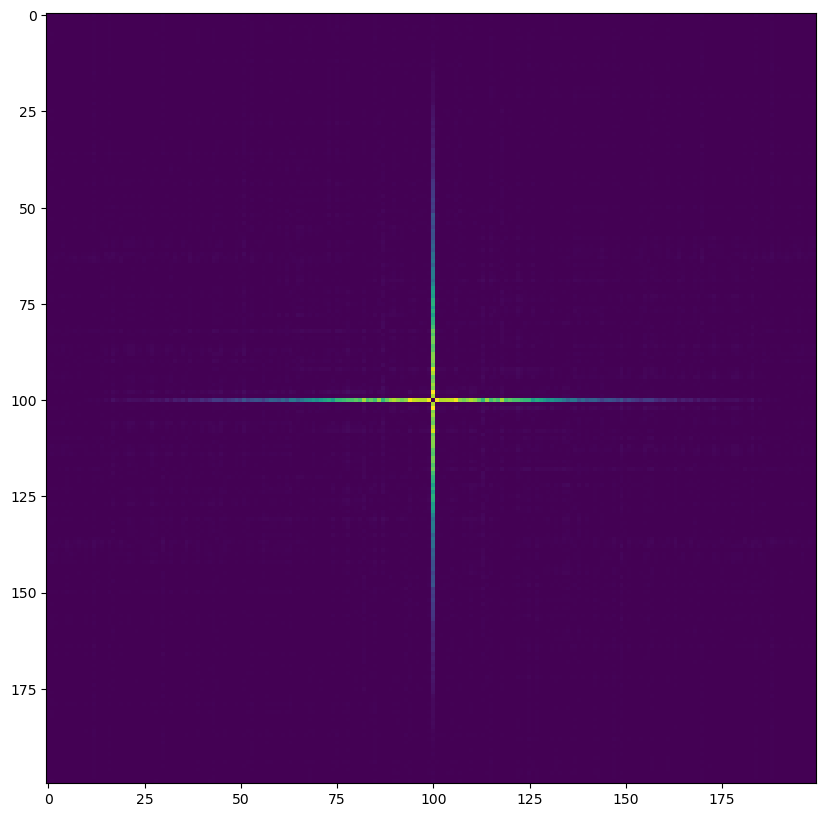

In [85]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

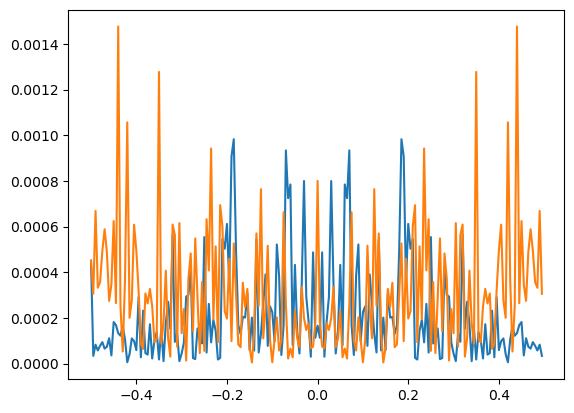

In [86]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [87]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

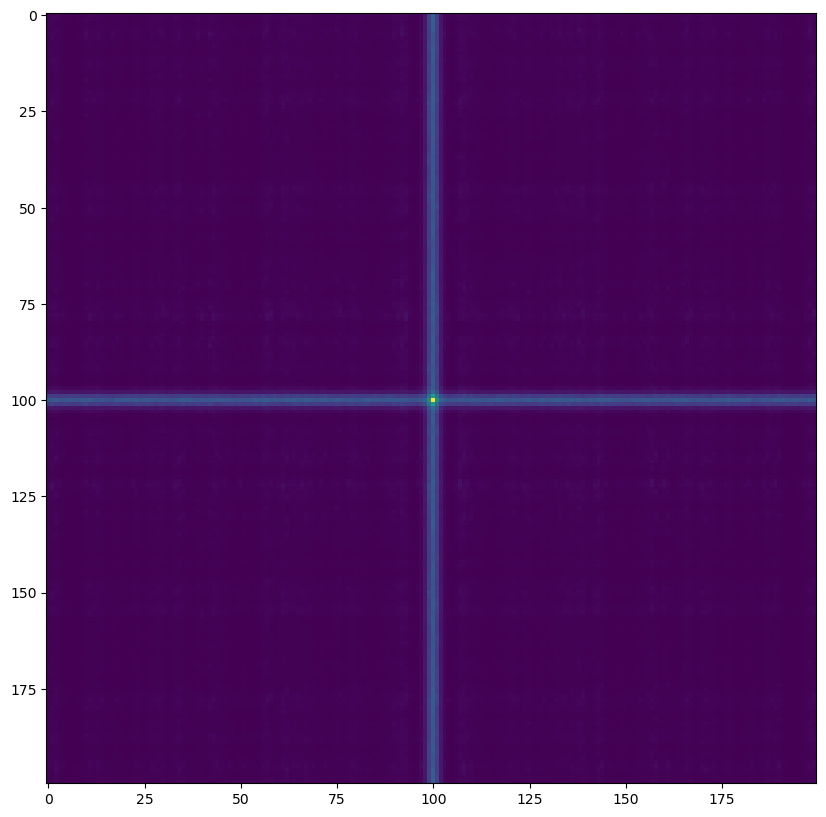

In [88]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

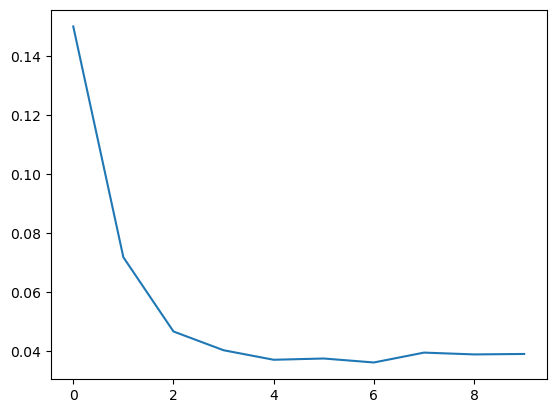

In [89]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()